In [28]:
# Importing libraries.
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


from scipy.spatial.distance import pdist
from scipy.stats import entropy
from skimage.metrics import structural_similarity as ssim

## Dataset Analysis

The Blood Serum microscopy dataset was inspected before training to verify:

- Number of images
- Image dimensions
- Channel information
- Dataset consistency
- Storage size

This ensures the dataset is valid and suitable for GB-RBM training.

In [29]:
# ===================== Dataset Analysis =====================

INPUT_FOLDER = "/content/drive/MyDrive/Mini project/Dataset/Blood serum images/Original dataset"

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".tif", ".tiff")

image_files = sorted([
    f for f in os.listdir(INPUT_FOLDER)
    if f.lower().endswith(VALID_EXTENSIONS)
])

sample_img = Image.open(
    os.path.join(INPUT_FOLDER, image_files[0])
)

dimensions = {
    Image.open(
        os.path.join(INPUT_FOLDER, f)
    ).size
    for f in image_files
}

dataset_size = sum(
    os.path.getsize(
        os.path.join(INPUT_FOLDER, f)
    )
    for f in image_files
) / (1024 * 1024)

print("Dataset Analysis\n")

print(f"Total Images       : {len(image_files)}")

print(f"Representative Img : {image_files[0]}")

print(f"Image Format       : {sample_img.format}")

print(f"Image Dimensions   : {sample_img.size}")

print(f"Channels           : {len(sample_img.getbands())}")

print(f"Dataset Size       : {dataset_size:.2f} MB")

print(
    f"Dimension Check    : {'Passed' if len(dimensions)==1 else 'Failed'}"
)

Dataset Analysis

Total Images       : 5
Representative Img : image10.jpg
Image Format       : JPEG
Image Dimensions   : (2529, 1947)
Channels           : 3
Dataset Size       : 4.45 MB
Dimension Check    : Passed


## Original Blood Serum Dataset

Five representative microscopy images are displayed below before preprocessing.

These images are later subjected to:

- Data augmentation
- Green channel extraction
- Gaussian blur
- Normalization
- Patch extraction

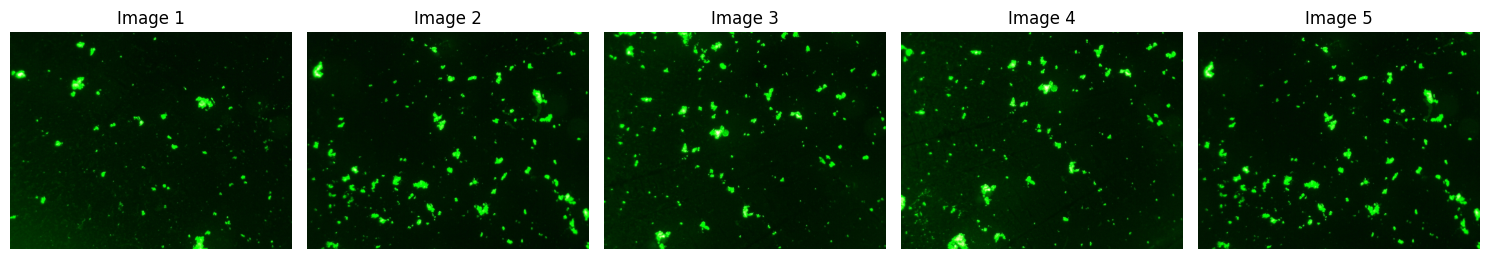

In [30]:
# Number of images to display
num_images_to_show = 5

# Select image files
selected_image_files = sorted(image_files)[:5]

fig, axes = plt.subplots(1, len(selected_image_files), figsize=(15, 5))

# If only one image is selected, axes might not be an array, so handle that case
if len(selected_image_files) == 1:
    axes = [axes]

for i, file_name in enumerate(selected_image_files):
    img_path = os.path.join(INPUT_FOLDER, file_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Augmentation

The Blood Serum dataset contains only **5 original microscopy images**, which is insufficient for effectively training a GB-RBM. Therefore, light microscopy-safe data augmentation techniques were applied to increase dataset diversity while preserving biological structures.

The following augmentations were used:

- Horizontal Flip
- Vertical Flip
- Rotation (+10°)
- Rotation (-10°)

These transformations increase the number of training images from **5 to 25** while maintaining the underlying image characteristics.


In [31]:
# ===================== Data Augmentation =====================

# Microscopy-safe augmentations
augmentations = [
    ("Horizontal Flip", transforms.RandomHorizontalFlip(p=1)),
    ("Vertical Flip", transforms.RandomVerticalFlip(p=1)),
    ("Rotation +10°", transforms.RandomRotation((10, 10))),
    ("Rotation -10°", transforms.RandomRotation((-10, -10)))
]

# Store original and augmented images
all_images = []
augmented_examples = []

# Process images
for file_name in sorted(image_files):
    img_path = os.path.join(INPUT_FOLDER, file_name)
    img = Image.open(img_path)

    # Store original image
    all_images.append(img)

    # Apply augmentations
    for aug_name, aug in augmentations:
        augmented_img = aug(img)
        all_images.append(augmented_img)

        # Save one example for visualization
        if len(augmented_examples) < 4:
            augmented_examples.append((aug_name, augmented_img))

# Summary
original_count = len(image_files)
augmented_count = original_count * len(augmentations)
total_count = len(all_images)

print("Data Augmentation Summary")
print(f"Original Images  : {original_count}")
print(f"Augmented Images : {augmented_count}")
print(f"Total Images     : {total_count}")

Data Augmentation Summary
Original Images  : 5
Augmented Images : 20
Total Images     : 25


## Visualize Original Image with Applied Augmentations

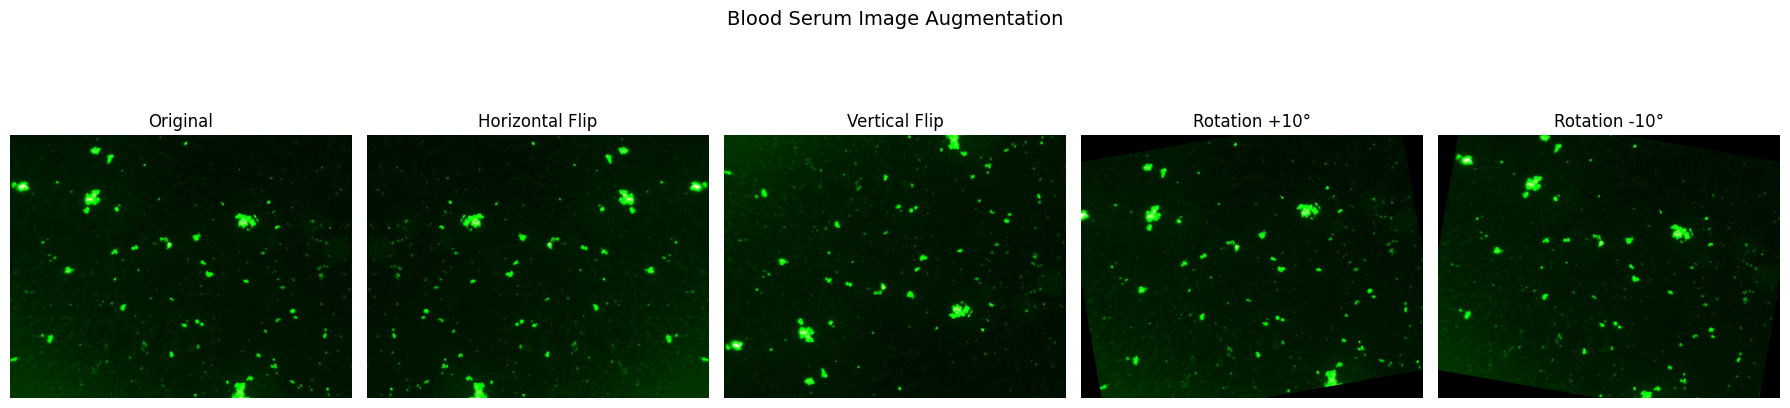

In [32]:
# ===================== Augmentation Visualization =====================

# Select the first image for reproducibility
sample_image_path = os.path.join(
    INPUT_FOLDER,
    sorted(image_files)[0]
)

sample_image = Image.open(sample_image_path)

# Create figure
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

# Display original image
axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[0].axis("off")

# Display augmented images
for i, (aug_name, aug) in enumerate(augmentations):
    augmented_image = aug(sample_image)
    axes[i + 1].imshow(augmented_image)
    axes[i + 1].set_title(aug_name)
    axes[i + 1].axis("off")

plt.suptitle(
    "Blood Serum Image Augmentation",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Data Preprocessing

The augmented microscopy images undergo three preprocessing steps:

1. Green channel extraction
2. Gaussian blur (3×3)
3. Pixel normalization (0-255 → 0-1)

These steps reduce noise and prepare the images for GB-RBM training.

In [33]:
# ===================== Data Preprocessing =====================

processed_images = []

for img in all_images:
    img = np.array(img)

    # Extract green channel
    if img.ndim == 3:
        img = img[:, :, 1]

    # Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3),0)

    # Normalize to [0,1]
    img = img.astype(np.float32) / 255.0
    processed_images.append(img)

# Summary
print("Preprocessing Summary\n")
print(f"Processed Images : {len(processed_images)}")
print(f"Image Shape      : {processed_images[0].shape}")
print(f"Data Type        : {processed_images[0].dtype}")
print(
    f"Pixel Range      : "
    f"{processed_images[0].min():.2f} "
    f"to "
    f"{processed_images[0].max():.2f}"
)

Preprocessing Summary

Processed Images : 25
Image Shape      : (1947, 2529)
Data Type        : float32
Pixel Range      : 0.03 to 1.00


## Preprocessing Visualization

A representative Blood Serum image is shown after each preprocessing step.

Pipeline:

Original RGB

↓

Green Channel Extraction

↓

Gaussian Blur (3×3)

↓

Normalization (0-1)

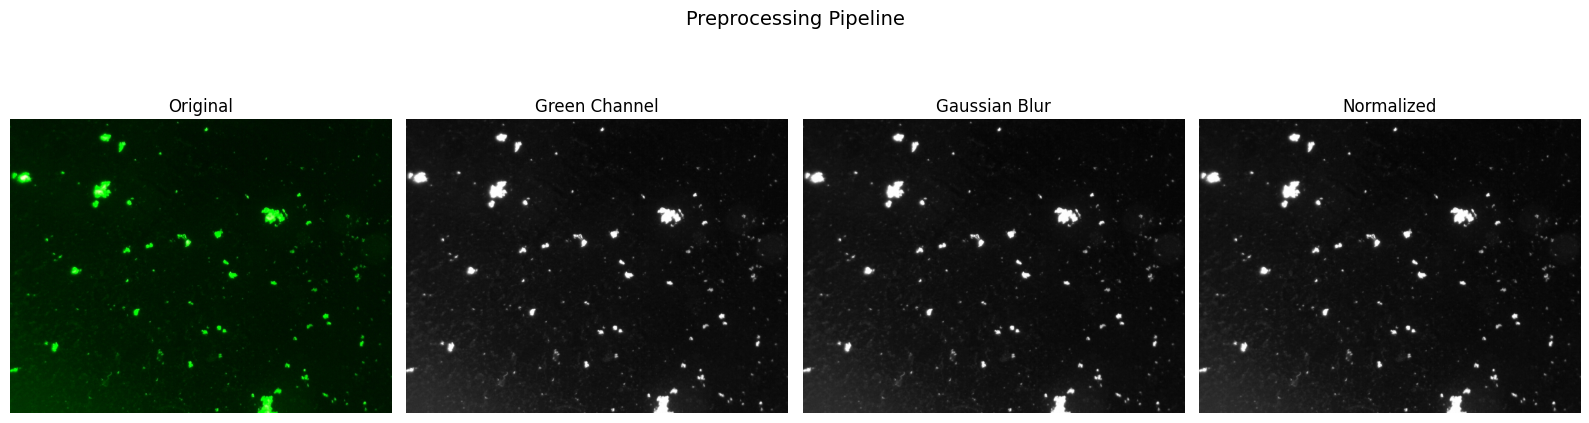

In [34]:
# ===================== Preprocessing Visualization =====================

# Select representative image
sample_image = np.array(
    Image.open(
        os.path.join(
            INPUT_FOLDER,
            sorted(image_files)[0]
        )
    )
)

# Apply preprocessing steps
green_channel = sample_image[:, :, 1]

blurred_image = cv2.GaussianBlur(green_channel, (3,3),0)

normalized_image = blurred_image.astype(np.float32)/255.0

# Images for visualization
images = [
    ("Original", sample_image),
    ("Green Channel", green_channel),
    ("Gaussian Blur", blurred_image),
    ("Normalized", normalized_image)
]

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (title, img) in zip(axes, images):
    ax.imshow(img, cmap = None if img.ndim == 3 else "gray")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(
    "Preprocessing Pipeline",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Patch Extraction

Large microscopy images are divided into overlapping 48×48 patches.

Parameters:

- Patch Size = 48×48
- Stride = 16

Only informative patches are retained based on:

- Standard deviation threshold
- Mean intensity threshold
- Bright pixel ratio threshold

This reduces background patches and preserves meaningful cellular information.

In [35]:
# ===================== Patch Extraction =====================

# Parameters
PATCH_SIZE = 48
STRIDE = 16
STD_THRESHOLD = 0.04
MEAN_THRESHOLD = 0.08
BRIGHT_THRESHOLD = 0.25
patches = []

# Extract informative patches
for img in processed_images:
    height, width = img.shape

    for y in range(0, height - PATCH_SIZE + 1,STRIDE):

        for x in range(0,  width - PATCH_SIZE + 1,STRIDE):
            patch = img[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

            if (
                np.std(patch) > STD_THRESHOLD
                and np.mean(patch) > MEAN_THRESHOLD
                and np.mean(patch > 0.85)
                < BRIGHT_THRESHOLD
            ):

                patches.append(patch)

patches = np.array(patches)

# Summary
print("Patch Extraction Summary\n")
print(f"Patch Shape : {patches.shape}")
print(f"Data Type   : {patches.dtype}")
print(
    f"Pixel Range : "
    f"{patches.min():.2f} "
    f"to "
    f"{patches.max():.2f}"
)

Patch Extraction Summary

Patch Shape : (78967, 48, 48)
Data Type   : float32
Pixel Range : 0.00 to 1.00


## Patch Visualization

Ten representative 48×48 patches are shown below.

These patches are used as training samples for the GB-RBM.

Only informative patches are retained after filtering out:

- Low-contrast regions
- Background regions
- Excessively bright regions

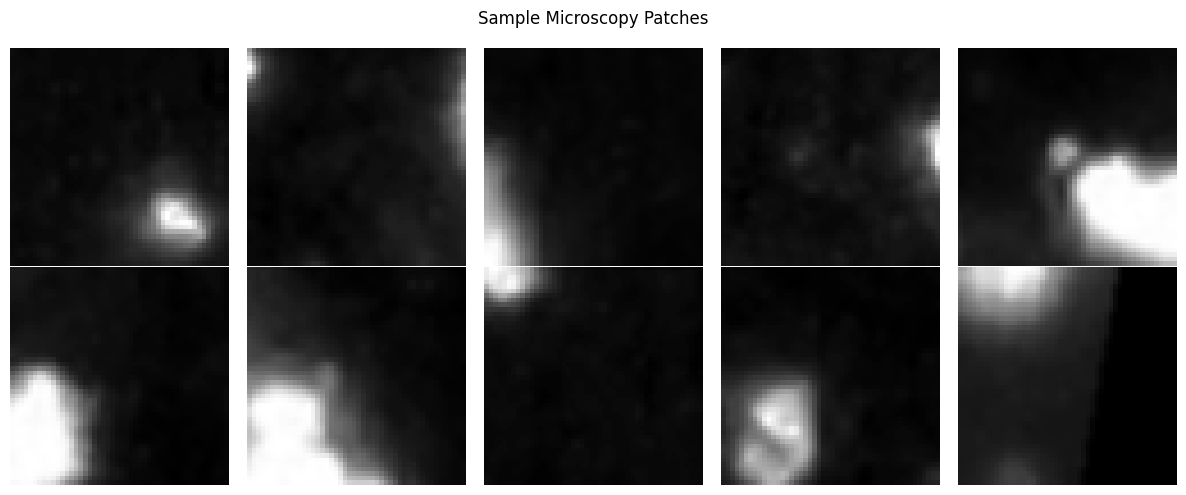

In [36]:
# ===================== Patch Visualization =====================

patch_indices = np.linspace(0, len(patches)-1, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, patch_indices):
    ax.imshow(patches[idx], cmap="gray")
    ax.axis("off")

plt.suptitle("Sample Microscopy Patches")
plt.tight_layout()
plt.show()

## Prepare Data for GB-RBM

Each 48×48 patch is flattened into a 2304-dimensional vector and converted into a PyTorch tensor.

The data is then organized into batches for efficient GB-RBM training.

In [37]:
# ===================== Prepare Data for GB-RBM =====================

# Flatten patches: (N,48,48) → (N,2304)
X = patches.reshape(len(patches), -1)

# Convert to tensor
X_tensor = torch.FloatTensor(X)

# Create dataset and dataloader
BATCH_SIZE = 64

dataset = TensorDataset(X_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Summary
print("Data Preparation Summary\n")
print(f"Patch Shape     : {patches.shape}")
print(f"Flattened Shape : {X.shape}")
print(f"Tensor Shape    : {X_tensor.shape}")
print(f"Training Samples: {len(dataset)}")
print(f"Batches         : {len(dataloader)}")

Data Preparation Summary

Patch Shape     : (78967, 48, 48)
Flattened Shape : (78967, 2304)
Tensor Shape    : torch.Size([78967, 2304])
Training Samples: 78967
Batches         : 1234


## Gaussian-Bernoulli RBM

The model consists of:

- 2304 visible units (48×48 patches)
- 512 hidden units

The visible layer models continuous pixel intensities using a Gaussian distribution, while the hidden layer uses Bernoulli units to learn latent image features.

In [38]:
# ===================== Gaussian-Bernoulli RBM =====================

class GaussianBernoulliRBM(nn.Module):

    def __init__(self, n_visible, n_hidden, noise_scale=0.001):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_visible, n_hidden) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))
        self.noise_scale = noise_scale

    # Visible → Hidden
    def sample_h(self, v):
        prob_h = torch.sigmoid(v @ self.W + self.h_bias)
        return prob_h, torch.bernoulli(prob_h)

    # Hidden → Visible
    def sample_v(self, h):
        mean_v = h @ self.W.T + self.v_bias
        sample_v = mean_v + torch.randn_like(mean_v) * self.noise_scale
        return mean_v, sample_v

## Model Initialization

GB-RBM Configuration:

- Visible Units = 2304
- Hidden Units = 512
- Learning Rate = 0.0005
- Batch Size = 64
- Epochs = 80

The model is trained using the Adam optimizer.

In [39]:
# ===================== Initialize GB-RBM =====================

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model parameters
N_VISIBLE = 48 * 48
N_HIDDEN = 512

# Training parameters
LEARNING_RATE = 0.0005
EPOCHS = 80
BATCH_SIZE = 64

# Initialize model
rbm = GaussianBernoulliRBM(
    n_visible=N_VISIBLE,
    n_hidden=N_HIDDEN,
    noise_scale=0.001
).to(device)

# Optimizer
optimizer = torch.optim.Adam(
    rbm.parameters(),
    lr=LEARNING_RATE
)

## Training the GB-RBM

The model is trained using Contrastive Divergence (CD-1).

Training techniques:

- Adam optimizer
- Gradient clipping (max norm = 5)
- 80 epochs
- Batch size = 64

The objective is to minimize reconstruction error while learning meaningful latent representations.

In [40]:
# ===================== Train GB-RBM =====================

epoch_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0

    for (v0,) in dataloader:
        v0 = v0.to(device)
        optimizer.zero_grad()

        # CD-1
        ph0, h0 = rbm.sample_h(v0)
        mean_vk, vk = rbm.sample_v(h0)
        phk, _ = rbm.sample_h(vk)

        # Reconstruction loss
        loss = torch.mean((v0 - mean_vk) ** 2)

        # Contrastive Divergence gradients
        positive_grad = v0.T @ ph0
        negative_grad = vk.T @ phk
        rbm.W.grad = -(positive_grad - negative_grad) / BATCH_SIZE
        rbm.v_bias.grad = -torch.mean(v0 - vk, dim=0)
        rbm.h_bias.grad = -torch.mean(ph0 - phk, dim=0)

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(rbm.parameters(), max_norm=5)
        optimizer.step()
        epoch_loss += loss.item()

    epoch_losses.append(epoch_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1:3d}/{EPOCHS}] "
            f"Loss: {epoch_loss:.6f}"
        )

print("\nTraining complete.")

Epoch [  1/80] Loss: 23.932972
Epoch [ 10/80] Loss: 11.078705
Epoch [ 20/80] Loss: 7.919900
Epoch [ 30/80] Loss: 7.225460
Epoch [ 40/80] Loss: 7.008357
Epoch [ 50/80] Loss: 6.914685
Epoch [ 60/80] Loss: 6.857621
Epoch [ 70/80] Loss: 6.778883
Epoch [ 80/80] Loss: 6.756159

Training complete.


## Reconstruction Test

Three microscopy patches are reconstructed using the trained GB-RBM.

Reconstruction quality indicates how well the model has learned the underlying data distribution.

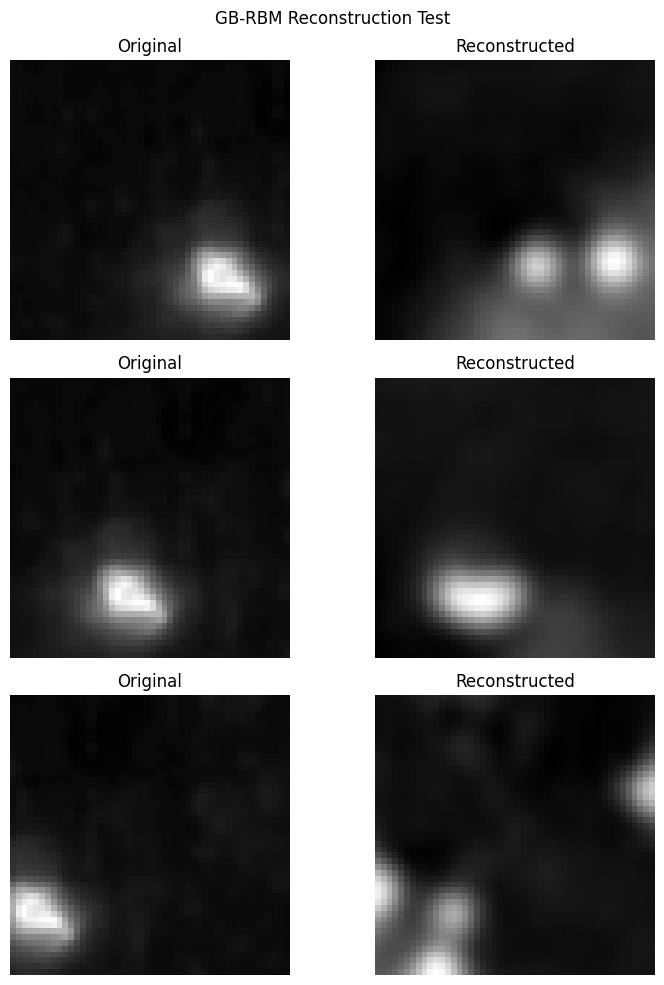

In [41]:
# ===================== Reconstruction Test =====================

num_examples = 3

fig, axes = plt.subplots(num_examples, 2, figsize=(8, 10))

for i in range(num_examples):
    idx = i
    original = X_tensor[idx:idx+1].to(device)
    ph, h = rbm.sample_h(original)
    mean_v, _ = rbm.sample_v(h)
    original_img = original.cpu().numpy().reshape(48, 48)
    reconstructed_img = mean_v.detach().cpu().numpy().reshape(48, 48)
    axes[i,0].imshow(original_img, cmap="gray")
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")
    axes[i,1].imshow(reconstructed_img, cmap="gray")
    axes[i,1].set_title("Reconstructed")
    axes[i,1].axis("off")

plt.suptitle("GB-RBM Reconstruction Test")
plt.tight_layout()
plt.show()

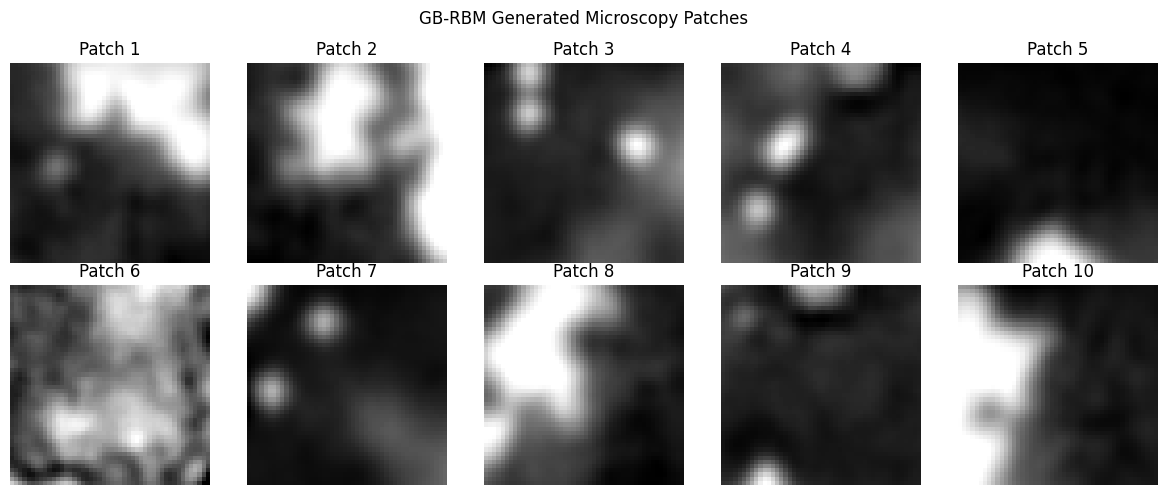

In [42]:
# ===================== Generate Microscopy Patches =====================

NUM_GENERATED = 10
GIBBS_STEPS = 50

generated_patches = []

for _ in range(NUM_GENERATED):
    idx = np.random.randint(len(X_tensor))
    v = X_tensor[idx:idx+1].to(device)

    for _ in range(GIBBS_STEPS):
        _, h = rbm.sample_h(v)
        mean_v, _ = rbm.sample_v(h)
        v = torch.clamp(mean_v, 0, 1)
    generated_patches.append(
        v.detach().cpu().numpy().reshape(48,48)
    )

generated_patches = np.array(generated_patches)

# Visualization
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_patches[i], cmap="gray")
    ax.set_title(f"Patch {i+1}")
    ax.axis("off")

plt.suptitle("GB-RBM Generated Microscopy Patches")

plt.tight_layout()
plt.show()

In [43]:
# ===================== Final Evaluation =====================

NUM_TEST = 100

mse_scores, ssim_scores = [], []

# Reconstruction metrics
for _ in range(NUM_TEST):

    idx = np.random.randint(len(X_tensor))

    original = X_tensor[idx:idx+1].to(device)

    _, h = rbm.sample_h(original)

    mean_v, _ = rbm.sample_v(h)

    original_img = original.cpu().numpy().reshape(48,48)

    reconstructed_img = mean_v.detach().cpu().numpy().reshape(48,48)

    mse_scores.append(
        np.mean((original_img - reconstructed_img)**2)
    )

    ssim_scores.append(
        ssim(
            original_img,
            reconstructed_img,
            data_range=1.0
        )
    )

avg_mse = np.mean(mse_scores)

avg_ssim = np.mean(ssim_scores)

# Diversity Score
generated_flat = generated_patches.reshape(
    len(generated_patches),
    -1
)

diversity_score = np.mean(
    pdist(
        generated_flat,
        metric="euclidean"
    )
)

# KL Divergence
real_hist, _ = np.histogram(
    X.flatten(),
    bins=50,
    range=(0,1),
    density=True
)

generated_hist, _ = np.histogram(
    generated_patches.flatten(),
    bins=50,
    range=(0,1),
    density=True
)

real_hist += 1e-10

generated_hist += 1e-10

kl_div = entropy(real_hist, generated_hist)

# Final report
print("Final Evaluation\n")
print(f"MSE           : {avg_mse:.6f}")
print(f"SSIM          : {avg_ssim:.6f}")
print(f"Diversity     : {diversity_score:.6f}")
print(f"KL Divergence : {kl_div:.6f}")

Final Evaluation

MSE           : 0.005600
SSIM          : 0.728151
Diversity     : 16.545880
KL Divergence : 0.144318
